# set up

In [8]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

import copy
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
sns.set_theme()

import torch
from torch.autograd import Variable
from torch.nn import functional as F

In [2]:
# Use self trained K-means results, which have a better likelihood
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [3]:
# Load LFP data
start_time = 0.0
end_time = 0.5
padding = 0.5
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# Membership

In [6]:
membership[0]

,probe,group_id
unit_ids,,
951814834,probeA,2
951814827,probeA,1
951814874,probeA,2
951814839,probeA,1
951814898,probeA,1
...,...,...
951804296,probeF,2
951804325,probeF,2
951804346,probeF,2


In [19]:
# Find total number of neurons needed and their corresponding trials where they are classified as cross-pop
target_probe = 'probeD'
cross_pop_list = []
cross_pop_conditions = {}
for neuron in membership[0].index:
    if membership[1].loc[neuron]['probe'] == target_probe:
        for i, member in enumerate(membership):
            if member.loc[neuron]['group_id'] == 0:
                if neuron not in cross_pop_conditions:
                    cross_pop_list.append(neuron)
                    cross_pop_conditions[neuron] = [condition_ids[i]]
                else:
                    cross_pop_conditions[neuron].append(condition_ids[i])
major_cross_pop_list = []
for neuron in cross_pop_list:
    if len(cross_pop_conditions[neuron])>= 40:
        major_cross_pop_list.append(neuron)
n_neuron = len(major_cross_pop_list)

In [20]:
# Neurons that are classified as cross-pop in at least one conditions.
cross_pop_list

[951810863,
 951810983,
 951811026,
 951811015,
 951812383,
 951811152,
 951811141,
 951812394,
 951811203,
 951811292,
 951811282,
 951811302,
 951812405,
 951811389,
 951811428,
 951811497,
 951811674,
 951811873,
 951812614]

In [21]:
# Neurons that 
major_cross_pop_list

[951810983, 951811026, 951811015]

# Fit a single neuron for example

In [255]:
# Select neuron and get spike trains
spike_train_ind = np.zeros((V1.nt+V1.npadding, V1.spike_train.shape[1]))
for itrial in range(V1.spike_train.shape[1]):
    spike_train_ind[:,itrial] = V1.spike_train.loc[951811026, V1.spike_train.columns[itrial]]


Using time warping parameters fitted from population helps reduce AIC of single neuron GLM a little bit. 

In [148]:
### Get time shifts (time warping parameters)

# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeD'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
# model_stationary.fit_time_warping_baseline(spike_train_ind[:,select_trials], method='mine', verbose=False, 
#                                            max_iter=max_iter, penalty=penalty)
model_stationary.fit_time_warping_baseline(target_probe, method='mine', verbose=False, 
                                           max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, method='mine', verbose=False, 
                                        max_iter=max_iter, penalty=penalty)

fix_shifts_stationary = model_stationary.shifts
fix_shifts_running = model_running.shifts

## Fit with time warping

In [256]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeD'
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':10, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 20
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('coupling', spike_train_ind[:,select_trials], **coupling_filter_params1, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(spike_train_ind[:,select_trials], method='mine', verbose=False, 
                                           max_iter=max_iter, penalty=penalty, fix_shifts=fix_shifts_stationary)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('coupling', spike_train_ind[:,select_trials], **coupling_filter_params1, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(spike_train_ind[:,select_trials], method='mine', verbose=False, 
                                        max_iter=max_iter, penalty=penalty, fix_shifts=fix_shifts_running)

In [257]:
model_stationary.aic, model_running.aic

(5193.176985368807, 6254.1104567548355)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


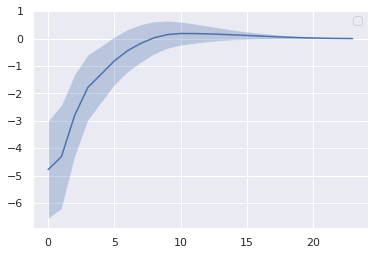

In [258]:
GLM.plot_GLM_one_effect(model_stationary, 7)

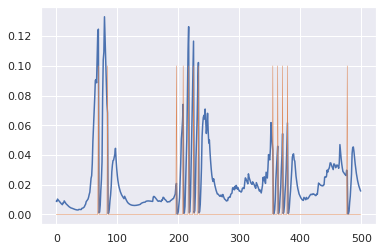

In [259]:
trial = 6
select_trials = V1.stationary_trial_index

sp = spike_train_ind[:,select_trials]
plt.plot(np.exp(model_stationary.log_lmbd)[:, trial])
plt.plot(0.1*sp[V1.npadding:, trial], linewidth=0.5)

## Fit with non warping

In [251]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeD'
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':10, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 20
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('coupling', spike_train_ind[:,select_trials], **coupling_filter_params1, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit(spike_train_ind[:,select_trials], method='mine', verbose=False, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('coupling', spike_train_ind[:,select_trials], **coupling_filter_params1, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit(spike_train_ind[:,select_trials], method='mine', verbose=False, penalty=penalty)

In [252]:
model_stationary.aic, model_running.aic

(5200.835380850771, 6254.282081676549)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


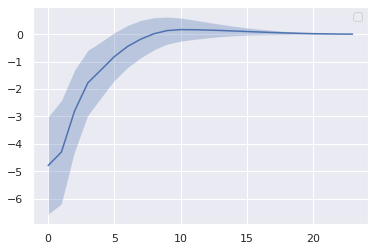

In [253]:
GLM.plot_GLM_one_effect(model_stationary, 7)

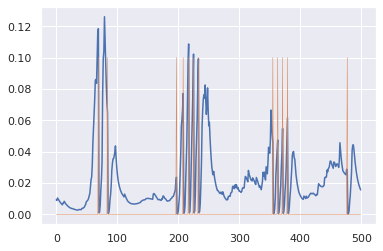

In [254]:
trial = 6
select_trials = V1.stationary_trial_index

sp = spike_train_ind[:,select_trials]
plt.plot(np.exp(model_stationary.log_lmbd)[:, trial])
plt.plot(0.1*sp[V1.npadding:, trial], linewidth=0.5)

# Get individual neuron's log_lmbd and self-history (refractory) component

In [172]:
 ### Get time shifts (time warping parameters)
fix_shifts_stationary_all = {}
fix_shifts_running_all = {}

for target_probe in tqdm(probe_list):

    max_iter = 10
    self_effect = False
    tau = 10
    coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
    coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
    coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
    num_basis_baseline = 30
    penalty = 3e-1

    ########## Nothing need to be changed below
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    # model_stationary.fit_time_warping_baseline(spike_train_ind[:,select_trials], method='mine', verbose=False, 
    #                                            max_iter=max_iter, penalty=penalty)
    model_stationary.fit_time_warping_baseline(target_probe, method='mine', verbose=False, 
                                               max_iter=max_iter, penalty=penalty)

    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, method='mine', verbose=False, 
                                            max_iter=max_iter, penalty=penalty)

    fix_shifts_stationary_all[target_probe] = model_stationary.shifts
    fix_shifts_running_all[target_probe] = model_running.shifts

100%|██████████████████████████████████████| 6/6 [03:39<00:00, 36.60s/it]


In [138]:
### Get the id of neurons that are classified as cross-pop
cross_pop_list_all = {}

for target_probe in probe_list:
    cross_pop_list = []
    cross_pop_conditions = {}
    for neuron in membership[0].index:
        if membership[1].loc[neuron]['probe'] == target_probe:
            for i, member in enumerate(membership):
                if member.loc[neuron]['group_id'] == 0:
                    if neuron not in cross_pop_conditions:
                        cross_pop_list.append(neuron)
                        cross_pop_conditions[neuron] = [condition_ids[i]]
                    else:
                        cross_pop_conditions[neuron].append(condition_ids[i])
    cross_pop_list_all[target_probe] = cross_pop_list

In [176]:
log_lmbd_ind_neuron_stationary = {}
log_lmbd_ind_neuron_running = {}
refractory_ind_neuron_stationary = {}
refractory_ind_neuron_running = {}

for target_probe in probe_list:
    for neuron in tqdm(cross_pop_list_all[target_probe]):
        # Get spike train of the neuron first
        spike_train_ind = np.zeros((V1.nt+V1.npadding, V1.spike_train.shape[1]))
        for itrial in range(V1.spike_train.shape[1]):
            spike_train_ind[:,itrial] = V1.spike_train.loc[neuron, V1.spike_train.columns[itrial]]

        max_iter = 10
        self_effect = False
        coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
        penalty = 3e-1
        
        ### Stationary
        num_basis_baseline = 20
        select_trials = V1.stationary_trial_index
        model_stationary = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
        for j, input_probe in enumerate(probe_list):
            model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
        model_stationary.add_effect('coupling', spike_train_ind[:,select_trials], **coupling_filter_params, apply_no_penalty=True)
        model_stationary.add_effect('trial_coef')
        model_stationary.fit_time_warping_baseline(spike_train_ind[:,select_trials], method='mine', verbose=False, 
                                                   max_iter=max_iter, penalty=penalty, 
                                                   fix_shifts=fix_shifts_stationary_all[target_probe],
                                                  no_penalty_term_penalty=1e-2)
        log_lmbd_ind_neuron_stationary[neuron] = model_stationary.log_lmbd
        refractory_ind_neuron_stationary[neuron] = model_stationary.get_filter_output(trial_wise=True)[7]. \
                                                    reshape((model_stationary.nt, model_stationary.ntrial), order='F')
        
        ### Running
        num_basis_baseline = 20
        
        select_trials = V1.running_trial_index
        model_running = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
        for j, input_probe in enumerate(probe_list):
            model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
        model_running.add_effect('coupling', spike_train_ind[:,select_trials], **coupling_filter_params, apply_no_penalty=True)
        model_running.add_effect('trial_coef')
        model_running.fit_time_warping_baseline(spike_train_ind[:,select_trials], method='mine', verbose=False, 
                                                max_iter=max_iter, penalty=penalty, 
                                                fix_shifts=fix_shifts_running_all[target_probe],
                                               no_penalty_term_penalty=1e-2)
        log_lmbd_ind_neuron_running[neuron] = model_running.log_lmbd
        refractory_ind_neuron_running[neuron] = model_running.get_filter_output(trial_wise=True)[7]. \
                                                    reshape((model_running.nt, model_running.ntrial), order='F')

100%|████████████████████████████████████| 18/18 [01:22<00:00,  4.59s/it]


# Get "ground truth" firing rate for population

In [263]:
log_lmbd_gt_all = {'stationary':{}, 'running':{}}
log_lmbd_gt_refractory_all = {'stationary':{}, 'running':{}}

for target_probe in probe_list:
    trial_type = 'stationary'
    model = model_stationary
    select_trials = V1.stationary_trial_index
    log_lmbd_ind_neuron = log_lmbd_ind_neuron_stationary
    refractory_ind_neuron = refractory_ind_neuron_stationary

    lmbd_gt = np.zeros((model.nt, model.ntrial))
    lmbd_gt_wo_refractor = np.zeros((model.nt, model.ntrial))
    condition_list = V1.presentation_table[select_trials]['stimulus_condition_id']

    for itrial in range(model.ntrial):
        current_condition = condition_list.iloc[itrial]
        current_membership = membership[np.where(condition_ids==current_condition)[0][0]]
        idx = current_membership[(current_membership['probe']==target_probe) \
            & (current_membership['group_id']==0)].index.values
        for neuron in idx:
            lmbd_gt[:, itrial] += np.exp(log_lmbd_ind_neuron[neuron][:, itrial])
            lmbd_gt_wo_refractor[:, itrial] += np.exp(log_lmbd_ind_neuron[neuron][:, itrial] - \
                                                      refractory_ind_neuron[neuron][:, itrial])
    log_lmbd_gt = np.log(lmbd_gt)
    log_lmbd_gt_refractory = log_lmbd_gt - np.log(lmbd_gt_wo_refractor)
    log_lmbd_gt_all[trial_type][target_probe] = log_lmbd_gt
    log_lmbd_gt_refractory_all[trial_type][target_probe] = log_lmbd_gt_refractory
    
    trial_type = 'running'
    model = model_running
    select_trials = V1.running_trial_index
    log_lmbd_ind_neuron = log_lmbd_ind_neuron_running
    refractory_ind_neuron = refractory_ind_neuron_running

    lmbd_gt = np.zeros((model.nt, model.ntrial))
    lmbd_gt_wo_refractor = np.zeros((model.nt, model.ntrial))
    condition_list = V1.presentation_table[select_trials]['stimulus_condition_id']

    for itrial in range(model.ntrial):
        current_condition = condition_list.iloc[itrial]
        current_membership = membership[np.where(condition_ids==current_condition)[0][0]]
        idx = current_membership[(current_membership['probe']==target_probe) \
            & (current_membership['group_id']==0)].index.values
        for neuron in idx:
            lmbd_gt[:, itrial] += np.exp(log_lmbd_ind_neuron[neuron][:, itrial])
            lmbd_gt_wo_refractor[:, itrial] += np.exp(log_lmbd_ind_neuron[neuron][:, itrial] - \
                                                      refractory_ind_neuron[neuron][:, itrial])
    log_lmbd_gt = np.log(lmbd_gt)
    log_lmbd_gt_refractory = log_lmbd_gt - np.log(lmbd_gt_wo_refractor)
    log_lmbd_gt_all[trial_type][target_probe] = log_lmbd_gt
    log_lmbd_gt_refractory_all[trial_type][target_probe] = log_lmbd_gt_refractory

In [276]:
aic = 0
for i, target_probe in enumerate(probe_list):
    aic += GLM.spike_trains_neg_log_likelihood(log_lmbd_gt_all['stationary'][target_probe], 
                                               stationary_model_list[i].output)
    aic += GLM.spike_trains_neg_log_likelihood(log_lmbd_gt_all['running'][target_probe], 
                                               running_model_list[i].output)
aic-baseline_aic

2913.3265770539874

In [ ]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

xx = np.linspace(np.log(1e-3), np.log(5), 1000)
plt.plot(np.exp(xx), np.exp(GLM.f_correct(xx, a=-0.15, intecept=-0.5)))

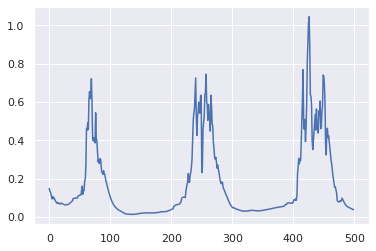

In [272]:
plt.plot(np.exp(log_lmbd_gt_all['stationary']['probeD'][:, 85]))

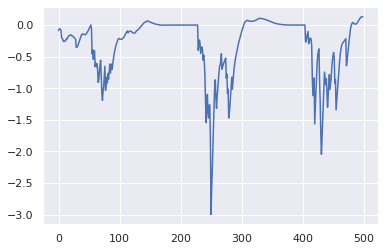

In [274]:
plt.plot(log_lmbd_gt_refractory_all['stationary']['probeD'][:, 85])

# Refractory $\Lambda^{1.5}$

In [277]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 5
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', target_probe, tau=tau, order=2, **coupling_filter_params, 
                            apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', target_probe, tau=tau, order=2, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
baseline_aic = aic
print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")


# model_list = stationary_model_list + running_model_list

# n_bin = 100
# dd = 0.05
# spike_sum = np.zeros(n_bin)
# num_sum = np.zeros(n_bin)
# for model in model_list:
#     for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
#         idx = int(lmbd/dd)
#         if idx<n_bin:
#             spike_sum[idx] += model.output.flatten('F')[idata]
#             num_sum[idx] += 1
# xx = np.linspace(0, n_bin*dd, n_bin)
# plt.subplots(figsize=(5,4.9))
# plt.plot(xx, xx, label='model prediction',color='r')
# plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
# plt.legend()
# plt.xlabel('Predicted firing rate for a bin')
# plt.ylabel('Observed probability of firing')
# plt.xlim([0, 5])
# plt.ylim([0, 5])

# xx = np.linspace(np.log(1e-3), np.log(5), 1000)
# plt.plot(np.exp(xx), np.exp(GLM.f_correct(xx, a=-0.15, intecept=-0.5)))

6it [03:39, 36.65s/it]

AIC improvement of the model is: 0.0


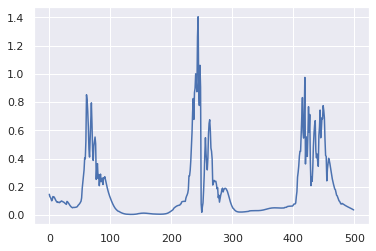

In [275]:
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]))

# Refractory nonparametric (quantile)

In [856]:
# The following hyperparameters turned out to be the best
num_f_refractory = 5
max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
#     model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, method='mine', verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
#     model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, method='mine', verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")

6it [03:35, 35.96s/it]

AIC improvement of the model is: 1733.6660469911294


Text(0, 0.5, '$f_{refractory}(\\Lambda)$')

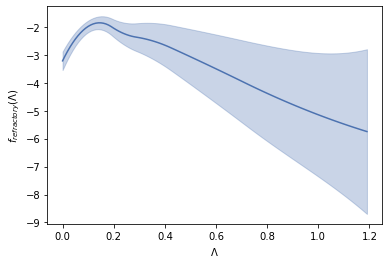

In [857]:
model = stationary_model_list[3]
utils.plot_ci(model.get_filter(ci=True)[7], x=model.f_refractory_xx)
plt.xlabel('$\Lambda$')
plt.ylabel('$f_{refractory}(\Lambda)$')
# plt.ylim([-5, 0])

Text(0.5, 0, 'time (ms)')

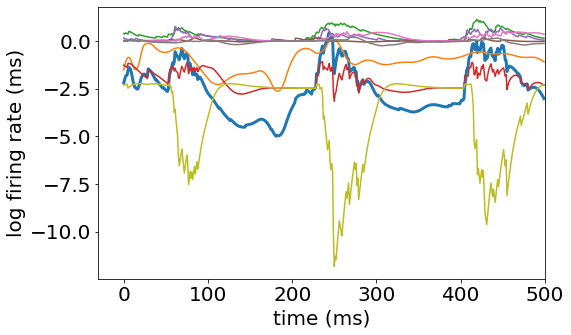

In [750]:
to_look_at = 3
import copy
model = stationary_model_list[to_look_at]
outputs = [model.get_filter_output(trial_wise=True, ci=False)[i].\
           reshape((model.nt, model.ntrial), order='F')  for i in range(9)]
outputs[to_look_at+1] += outputs[7]
outputs[0] += outputs[8]
total_output = copy.deepcopy( outputs[0] )
for i in range(1, 7):
    total_output += outputs[i]

sns.reset_orig()
trial = 85
plot_order = [0,3,4,5,6,1,2, 7]
fontsize = 20

fig, ax = plt.subplots(figsize=(8,5))
ax.tick_params(axis='both', which='major', labelsize=fontsize)
plt.plot(total_output[:,trial], label='total', linewidth=3)
for i in range(8):
    output = outputs[plot_order[i]]
    plt.plot( output[:,trial], linewidth=1.5)
# plt.legend(['total firing rate of V1 (sum of all effects below)', 
#             'time-warped inhomogeneous baseline + trial-wise gain constant', 
#             'nonlinear self-history effect of V1', 
#             'coupling effect input from LM',
#             'coupling effect input from AL',
#             'coupling effect input from RL',
#             'coupling effect input from AM',
#             'coupling effect input from PM'])
plt.xlim([-30, 500])
plt.ylabel('log firing rate (ms)', fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)

/tmp/ipykernel_59720/776915597.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


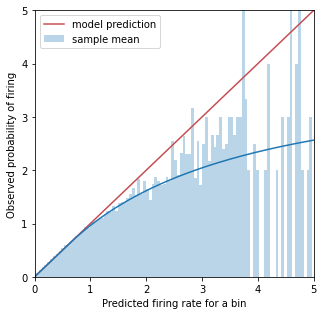

In [748]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

xx = np.linspace(np.log(1e-3), np.log(5), 1000)
plt.plot(np.exp(xx), np.exp(GLM.f_correct(xx, a=-0.15, intecept=-0.5)))